# EDA - Simulacro Autos

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTADOS = Path("resultados")
FIGURAS = RESULTADOS / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("data/autos.csv")

## 1. Comprensión de los datos

In [2]:
n_filas_original, n_columnas = df.shape
print(df.shape)
df.info()

(398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [3]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Nulos en columna horsepower

In [4]:
nulos_horsepower = int(df["horsepower"].isna().sum())
print(f"Nulos en horsepower: {nulos_horsepower}")

df_limpio = df.dropna(subset=["horsepower"]).reset_index(drop=True)
n_filas_limpio = len(df_limpio)
print(f"Filas limpias: {n_filas_limpio}")

df_limpio.to_csv("data/autos_limpio.csv", index=False)

Nulos en horsepower: 6
Filas limpias: 392


## Media y mediana de mpg

In [5]:
mpg_promedio = float(df_limpio["mpg"].mean())
mpg_mediano = float(df_limpio["mpg"].median())
print(f"Promedio mpg: {mpg_promedio:.2f}")
print(f"Mediana mpg: {mpg_mediano:.2f}")

Promedio mpg: 23.45
Mediana mpg: 22.75


## Correlacion weight-mpg

Correlacion weight-mpg: -0.8322


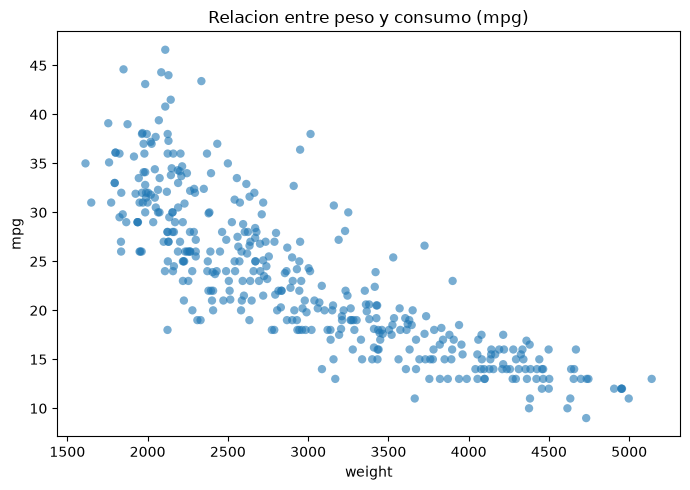

In [6]:
correlacion_weight_mpg = float(df_limpio["weight"].corr(df_limpio["mpg"]))
print(f"Correlacion weight-mpg: {correlacion_weight_mpg:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_limpio["weight"], df_limpio["mpg"], alpha=0.6, edgecolor="none")
ax.set_xlabel("weight")
ax.set_ylabel("mpg")
ax.set_title("Relacion entre peso y consumo (mpg)")
fig.tight_layout()
fig.savefig(FIGURAS / "scatter_weight_mpg.png", dpi=150)
plt.show()

## Mpg promedio por origin

{'europe': 27.6, 'japan': 30.45, 'usa': 20.03}
Origen mas eficiente: japan


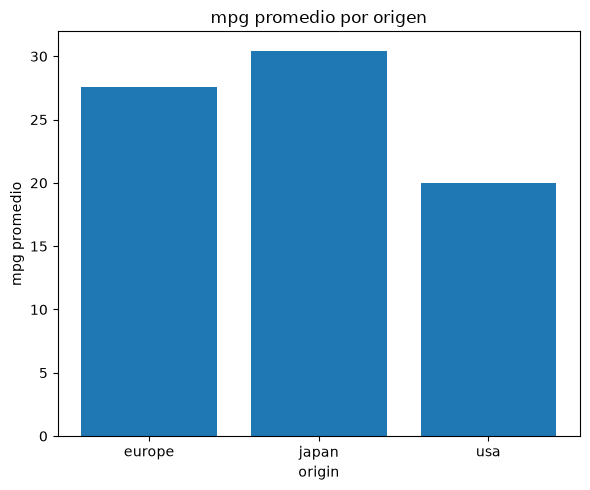

In [7]:
_por_origen = df_limpio.groupby("origin")["mpg"].mean().round(2).to_dict()
mpg_promedio_por_origen = {k: float(_por_origen[k]) for k in ["europe", "japan", "usa"]}
origen_mas_eficiente = max(mpg_promedio_por_origen, key=mpg_promedio_por_origen.get)
print(mpg_promedio_por_origen)
print(f"Origen mas eficiente: {origen_mas_eficiente}")

fig, ax = plt.subplots(figsize=(6, 5))
origenes = list(mpg_promedio_por_origen.keys())
valores = list(mpg_promedio_por_origen.values())
ax.bar(origenes, valores)
ax.set_xlabel("origin")
ax.set_ylabel("mpg promedio")
ax.set_title("mpg promedio por origen")
fig.tight_layout()
fig.savefig(FIGURAS / "mpg_por_origen.png", dpi=150)
plt.show()

## Hallazgos

In [8]:
hallazgos = {
    "n_filas_original": n_filas_original,
    "n_columnas": n_columnas,
    "nulos_horsepower": nulos_horsepower,
    "n_filas_limpio": n_filas_limpio,
    "mpg_promedio": round(mpg_promedio, 2),
    "mpg_mediano": round(mpg_mediano, 2),
    "correlacion_weight_mpg": round(correlacion_weight_mpg, 4),
    "mpg_promedio_por_origen": mpg_promedio_por_origen,
    "origen_mas_eficiente": origen_mas_eficiente,
    "mejor_modelo": "",
    "rmse_test_mejor_modelo": 0.0,
    "r2_test_mejor_modelo": 0.0,
}

with open(RESULTADOS / "hallazgos.json", "w", encoding="utf-8") as f:
    json.dump(hallazgos, f, indent=2, ensure_ascii=False)

hallazgos

{'n_filas_original': 398,
 'n_columnas': 9,
 'nulos_horsepower': 6,
 'n_filas_limpio': 392,
 'mpg_promedio': 23.45,
 'mpg_mediano': 22.75,
 'correlacion_weight_mpg': -0.8322,
 'mpg_promedio_por_origen': {'europe': 27.6, 'japan': 30.45, 'usa': 20.03},
 'origen_mas_eficiente': 'japan',
 'mejor_modelo': '',
 'rmse_test_mejor_modelo': 0.0,
 'r2_test_mejor_modelo': 0.0}

## Modelado y experimentos con MLflow

In [9]:
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

mlflow.set_tracking_uri("sqlite:///mlflow.db")

### Separar train/test

In [10]:
df_modelo = pd.read_csv("data/autos_limpio.csv")
cols = ["cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year"]
X, y = df_modelo[cols], df_modelo["mpg"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((313, 6), (79, 6))

### Experimento 1

In [11]:
mlflow.set_experiment("prediccion-eficiencia-autos")

2026/08/15 02:27:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/15 02:27:25 INFO mlflow.store.db.utils: Updating database tables


2026/08/15 02:27:25 INFO mlflow.tracking.fluent: Experiment with name 'prediccion-eficiencia-autos' does not exist. Creating a new experiment.


<Experiment: artifact_location='/workspace/mlruns/1', creation_time=1786760845846, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786760845846, lifecycle_stage='active', name='prediccion-eficiencia-autos', tags={}, trace_location=None, workspace='default'>

### Run 1: baseline-lineal

In [12]:
with mlflow.start_run(run_name="baseline-lineal"):
    modelo = LinearRegression()
    mlflow.log_param("modelo", "LinearRegression")

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mlflow.log_metric("rmse_test", root_mean_squared_error(y_test, pred))
    mlflow.log_metric("mae_test", mean_absolute_error(y_test, pred))
    mlflow.log_metric("r2_test", r2_score(y_test, pred))
    mlflow.sklearn.log_model(modelo, name="modelo")

2026/08/15 02:27:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



2026/08/15 02:27:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git branch is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



2026/08/15 02:27:25 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git repository URL is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



### Run 2: rf-100-5

In [13]:
with mlflow.start_run(run_name="rf-100-5"):
    modelo = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    mlflow.log_param("modelo", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mlflow.log_metric("rmse_test", root_mean_squared_error(y_test, pred))
    mlflow.log_metric("mae_test", mean_absolute_error(y_test, pred))
    mlflow.log_metric("r2_test", r2_score(y_test, pred))
    mlflow.sklearn.log_model(modelo, name="modelo")

### Run 3: rf-300-10

In [14]:
with mlflow.start_run(run_name="rf-300-10"):
    modelo = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
    mlflow.log_param("modelo", "RandomForestRegressor")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 10)

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mlflow.log_metric("rmse_test", root_mean_squared_error(y_test, pred))
    mlflow.log_metric("mae_test", mean_absolute_error(y_test, pred))
    mlflow.log_metric("r2_test", r2_score(y_test, pred))
    mlflow.sklearn.log_model(modelo, name="modelo")

### Selecionar ganador

In [15]:
tabla = mlflow.search_runs(order_by=["metrics.rmse_test ASC"])
run_id = tabla.iloc[0]["run_id"]
mejor_run_name = tabla.iloc[0]["tags.mlflow.runName"]
mejor_rmse = tabla.iloc[0]["metrics.rmse_test"]
mejor_r2 = tabla.iloc[0]["metrics.r2_test"]
mejor_run_name, mejor_rmse, mejor_r2

('rf-300-10', np.float64(2.4026977958294395), np.float64(0.8868947740868552))

### Actualizar hallazgos.json con el ganador

In [16]:
with open("resultados/hallazgos.json") as f:
    hallazgos = json.load(f)

hallazgos["mejor_modelo"] = mejor_run_name
hallazgos["rmse_test_mejor_modelo"] = round(float(mejor_rmse), 4)
hallazgos["r2_test_mejor_modelo"] = round(float(mejor_r2), 4)

with open("resultados/hallazgos.json", "w") as f:
    json.dump(hallazgos, f, indent=2)

hallazgos

{'n_filas_original': 398,
 'n_columnas': 9,
 'nulos_horsepower': 6,
 'n_filas_limpio': 392,
 'mpg_promedio': 23.45,
 'mpg_mediano': 22.75,
 'correlacion_weight_mpg': -0.8322,
 'mpg_promedio_por_origen': {'europe': 27.6, 'japan': 30.45, 'usa': 20.03},
 'origen_mas_eficiente': 'japan',
 'mejor_modelo': 'rf-300-10',
 'rmse_test_mejor_modelo': 2.4027,
 'r2_test_mejor_modelo': 0.8869}

### Registrar de modelo

In [17]:
res = mlflow.register_model(f"runs:/{run_id}/modelo", name="eficiencia-autos")
MlflowClient().set_registered_model_alias("eficiencia-autos", "champion", res.version)

Successfully registered model 'eficiencia-autos'.
2026/08/15 02:27:38 WARNING mlflow.tracking._model_registry.fluent: Run with id 8e5b3d10561b4d8c82d4ae4b19642b54 has no artifacts at artifact path 'modelo', registering model based on models:/m-04569cf9e23745f8bf870c26a0136dff instead


Created version '1' of model 'eficiencia-autos'.
